In [23]:
import networkx as nx
import matplotlib.pyplot as plt
import statistics
import numpy as np
import pandas as pd

In [13]:
G = nx.read_edgelist("network_output_2.edgelist", data=[("weight", float)])

# Check if it worked
print(f"Nodes: {len(G.nodes)}")
print(f"Edges: {len(G.edges)}")

Nodes: 12011
Edges: 66966


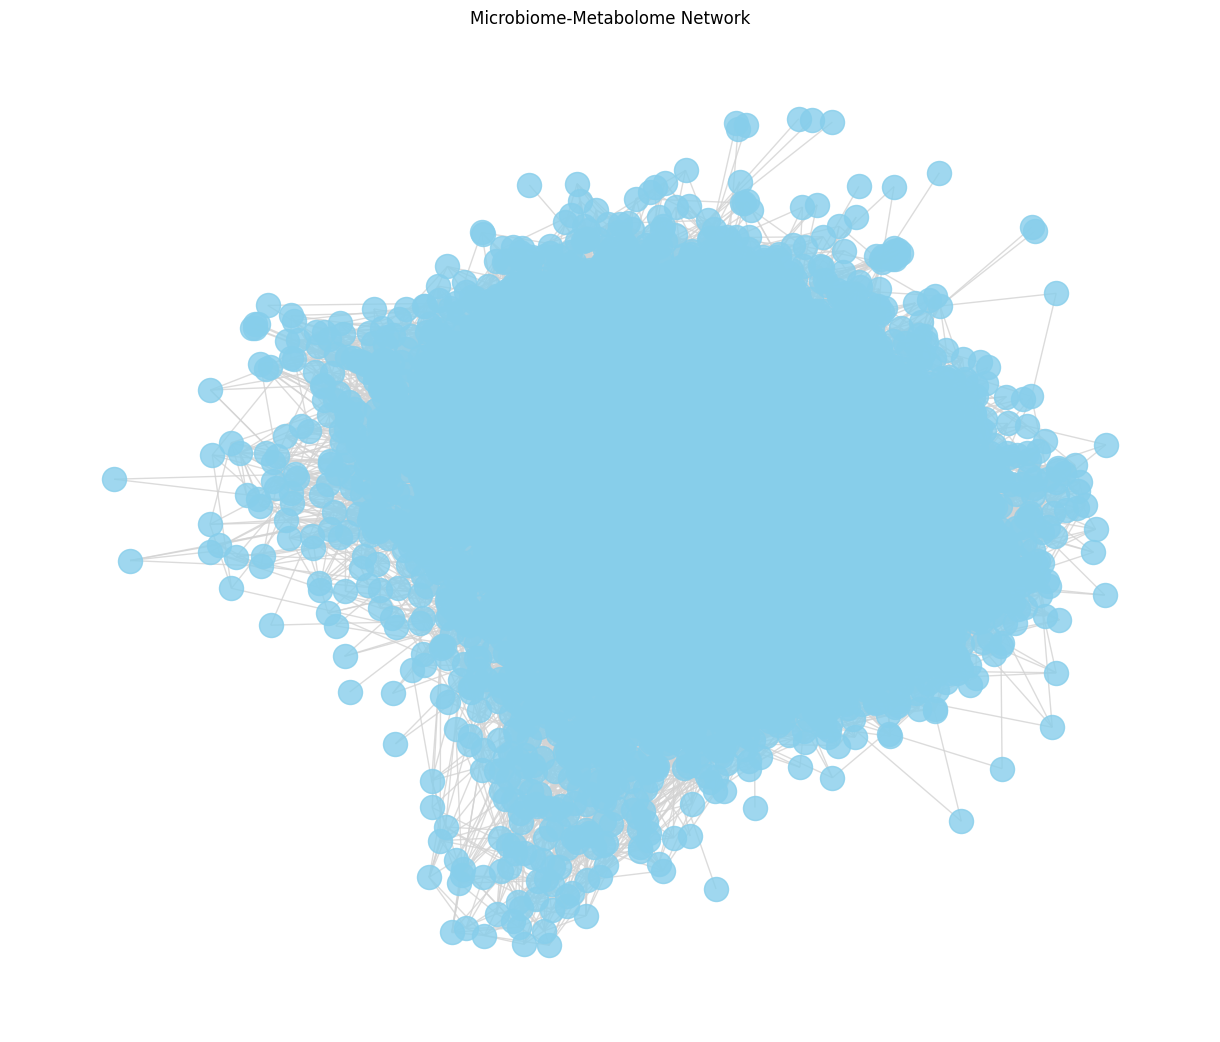

In [15]:
plt.figure(figsize=(12, 10))

# Create a layout for nodes
pos = nx.spring_layout(G, k=0.15, seed=42) 

# Draw the network
nx.draw(G, pos, 
        with_labels=False, 
        node_size=300, 
        node_color='skyblue', 
        edge_color='#D3D3D3', # Light gray for edges
        font_size=7, 
        alpha=0.8)

plt.title("Microbiome-Metabolome Network")
plt.show()

In [16]:
degree_sequence = [G.degree(n) for n in G.nodes]

In [19]:
print('Mean degree:', statistics.mean(degree_sequence))
print('Median degree:', statistics.median(degree_sequence))

Mean degree: 11.150778453084673
Median degree: 10


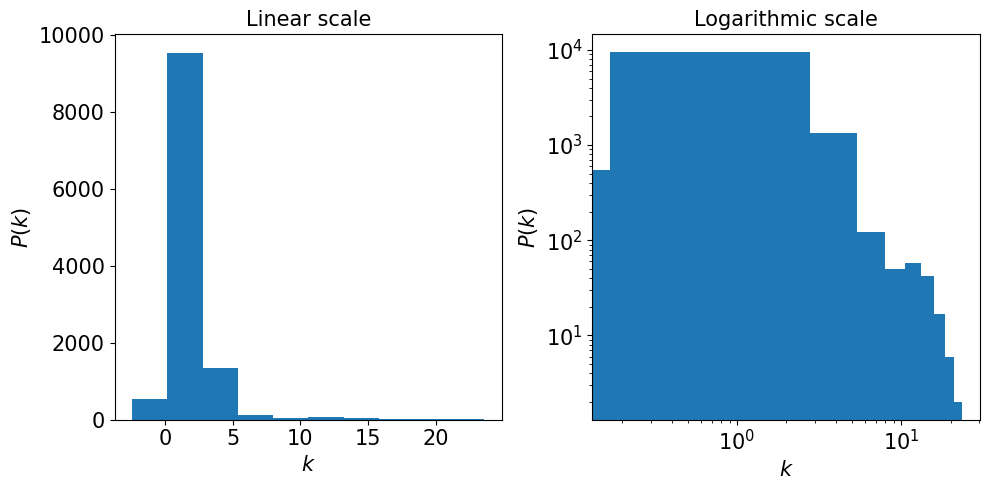

In [71]:

fig,ax=plt.subplots(1,2,figsize=(10,5))
degree_sequence=[G.degree(node, weight='weight') for node in G.nodes()]
from collections import Counter



ax[0].hist(degree_sequence, bins=10, label='data')
ax[1].hist(degree_sequence, bins=10, label='data')

ax[0].set_xlabel('$k$',fontsize=15)  ### Set label of the axis
ax[0].set_ylabel('$P(k)$',fontsize=15)

ax[1].set_xlabel('$k$',fontsize=15) ### Set label of the axis
ax[1].set_ylabel('$P(k)$',fontsize=15) 

ax[1].set_yscale('log') ### Set logarithmic scale
ax[1].set_xscale('log')

ax[0].tick_params(which='major',axis='both',labelsize=15) ### Size labels ticks
ax[1].tick_params(which='major',axis='both',labelsize=15)


ax[0].set_title('Linear scale',fontsize=15)
ax[1].set_title('Logarithmic scale',fontsize=15)
fig.tight_layout()



In [24]:
positive_weights = sum(1 for u, v, data in G.edges(data=True) if data.get('weight', 0) > 0)
negative_weights = sum(1 for u, v, data in G.edges(data=True) if data.get('weight', 0) < 0)
zero_weights = sum(1 for u, v, data in G.edges(data=True) if data.get('weight', 0) == 0)

print(f"Positive weights: {positive_weights}")
print(f"Negative weights: {negative_weights}")
print(f"Zero weights: {zero_weights}")

Positive weights: 65684
Negative weights: 1282
Zero weights: 0


In [2]:
def structural_characterization(G_net):
    #read the file
    #path = "activityA1/" + filename
    #G_net = nx.read_pajek(path)
    #G_net = nx.Graph(G_net)
    #print(f'Structural characterization of '+ filename +' network:')

    #primary characteristics
    print('Number of nodes:', G_net.number_of_nodes())
    print('Number of edges:', G_net.number_of_edges())

    #degree
    degrees = [d for _, d in G_net.degree()]

    min_degree = min(degrees)
    max_degree = max(degrees)
    avg_degree = sum(degrees) / len(degrees)

    print(f"Minimum Degree: {min_degree}")
    print(f"Maximum Degree: {max_degree}")
    print(f"Average Degree: {avg_degree:.2f}")

    #clustering
    avg_clustering = nx.average_clustering(G_net)
    print(f"Average Clustering Coefficient: {avg_clustering:.4f}")

    r = nx.degree_assortativity_coefficient(G_net)
    print(f"Assortativity Coefficient (r): {r:.4f}")

    #paths characteristics
    if nx.is_connected(G_net):
        avg_path = nx.average_shortest_path_length(G_net)
        d = nx.diameter(G_net)
    else:
        print("Graph is not connected, using largest connected component")
        largest_cc = max(nx.connected_components(G_net), key=len)
        G_lcc = G_net.subgraph(largest_cc)

        avg_path = nx.average_shortest_path_length(G_lcc)
        d = nx.diameter(G_lcc)

        

    print(f"Average Shortest Path Length: {avg_path:.2f}")
    print(f"Diameter: {d}")

    print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
    return G_net

# Healthy

In [92]:
G_healthy = nx.read_edgelist("network_healthy.edgelist", data=[("weight", float)])

In [97]:
structural_characterization(G_healthy)

Number of nodes: 10451
Number of edges: 22356
Minimum Degree: 1
Maximum Degree: 133
Average Degree: 4.28
Average Clustering Coefficient: 0.0097
Assortativity Coefficient (r): -0.1177
Graph is not connected, using largest connected component
Average Shortest Path Length: 6.59
Diameter: 15
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


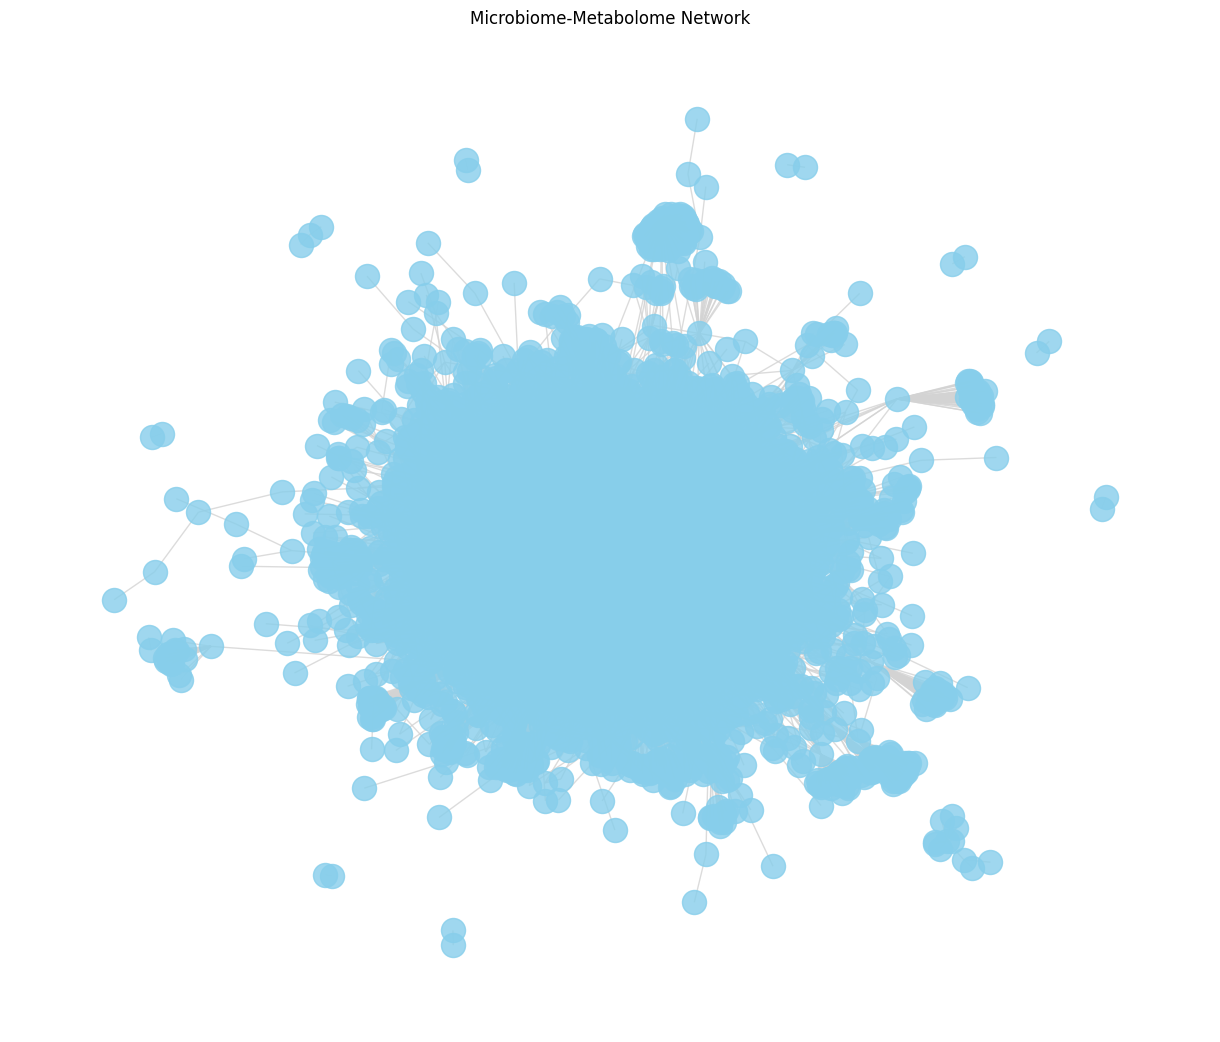

In [46]:
plt.figure(figsize=(12, 10))

# Create a layout for nodes
pos = nx.spring_layout(G_healthy, k=0.15, seed=42) 

# Draw the network
nx.draw(G_healthy, pos, 
        with_labels=False, 
        node_size=300, 
        node_color='skyblue', 
        edge_color='#D3D3D3', # Light gray for edges
        font_size=7, 
        alpha=0.8)

plt.title("Healthy Network")
plt.show()

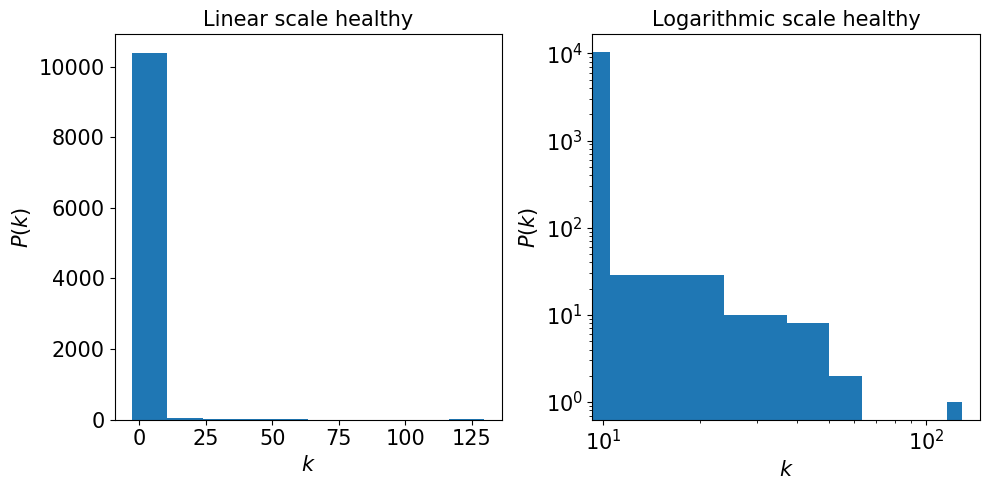

In [75]:

fig,ax=plt.subplots(1,2,figsize=(10,5))
degree_sequence=[G_healthy.degree(node, weight='weight') for node in G_healthy.nodes()]
from collections import Counter



ax[0].hist(degree_sequence, bins=10, label='data')
ax[1].hist(degree_sequence, bins=10, label='data')

ax[0].set_xlabel('$k$',fontsize=15)  ### Set label of the axis
ax[0].set_ylabel('$P(k)$',fontsize=15)

ax[1].set_xlabel('$k$',fontsize=15) ### Set label of the axis
ax[1].set_ylabel('$P(k)$',fontsize=15) 

ax[1].set_yscale('log') ### Set logarithmic scale
ax[1].set_xscale('log')

ax[0].tick_params(which='major',axis='both',labelsize=15) ### Size labels ticks
ax[1].tick_params(which='major',axis='both',labelsize=15)


ax[0].set_title('Linear scale healthy',fontsize=15)
ax[1].set_title('Logarithmic scale healthy',fontsize=15)
fig.tight_layout()



In [40]:
positive_weights = sum(1 for u, v, data in G_healthy.edges(data=True) if data.get('weight', 0) > 0)
negative_weights = sum(1 for u, v, data in G_healthy.edges(data=True) if data.get('weight', 0) < 0)
zero_weights = sum(1 for u, v, data in G_healthy.edges(data=True) if data.get('weight', 0) == 0)

print(f"Positive weights: {positive_weights}")
print(f"Negative weights: {negative_weights}")
print(f"Zero weights: {zero_weights}")

Positive weights: 19801
Negative weights: 2555
Zero weights: 0


In [61]:
connected_components=sorted(nx.connected_components(G_healthy),key=len,reverse=True)

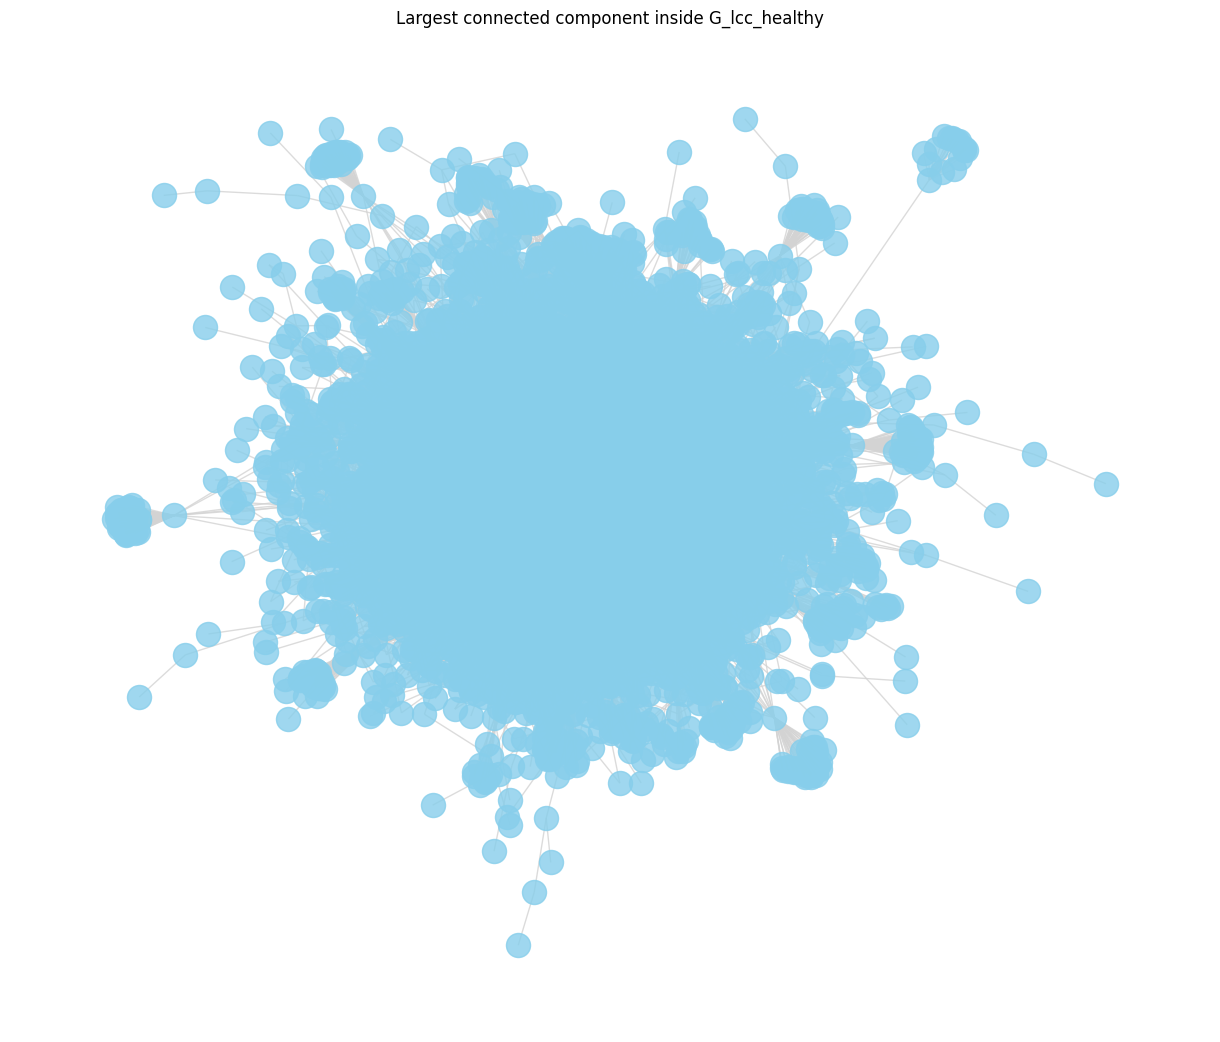

In [94]:
# plot the largest connected component inside G_healthy
lcc_healthy = max(nx.connected_components(G_healthy), key=len)
G_lcc_healthy = G_healthy.subgraph(lcc_healthy).copy()

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_lcc_healthy, k=0.15, seed=42)

nx.draw(G_lcc_healthy, pos,
	with_labels=False,
	node_size=300,
	node_color='skyblue',
	edge_color='#D3D3D3',
	alpha=0.8)

plt.title("Largest connected component inside G_lcc_healthy")
plt.show()

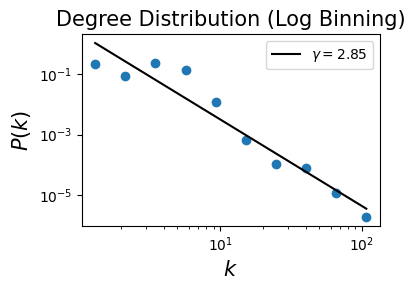

In [100]:
def plot_log_binning(G, num_bins=10):
    degree_sequence = [G.degree(n) for n in G.nodes() if G.degree(n) > 0]
    num_nodes = len(G.nodes())
    
    min_deg, max_deg = min(degree_sequence), max(degree_sequence)
    bins = np.logspace(np.log10(min_deg), np.log10(max_deg), num_bins + 1)
    
    counts, bin_edges = np.histogram(degree_sequence, bins=bins)
    
    # Normalize
    bin_widths = np.diff(bin_edges)
    density = counts / (num_nodes * bin_widths)
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    idx = density > 0
    log_k = np.log10(bin_centers[idx])
    log_P = np.log10(density[idx])
    
    m, b = np.polyfit(log_k, log_P, 1)
    
    theoretical_P = 10**(m * np.log10(bin_centers) + b)
    
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.scatter(bin_centers, density)

    ax.plot(bin_centers, theoretical_P, 'k-', label=f'$\\gamma = {-m:.2f}$')
    
    # Set both axes to log scale
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    ax.set_xlabel('$k$', fontsize=15)
    ax.set_ylabel('$P(k)$', fontsize=15)
    ax.set_title('Degree Distribution (Log Binning)', fontsize=15)
    ax.legend()

    fig.tight_layout()
    plt.show()

plot_log_binning(G_healthy, num_bins=10)

# Unhealthy

In [19]:
G_unhealthy = nx.read_edgelist("network_unhealthy.edgelist", data=[("weight", float)])

In [99]:
structural_characterization(G_unhealthy)

Number of nodes: 11709
Number of edges: 55118
Minimum Degree: 1
Maximum Degree: 63
Average Degree: 9.41
Average Clustering Coefficient: 0.0078
Assortativity Coefficient (r): -0.0945
Graph is not connected, using largest connected component
Average Shortest Path Length: 4.41
Diameter: 8
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


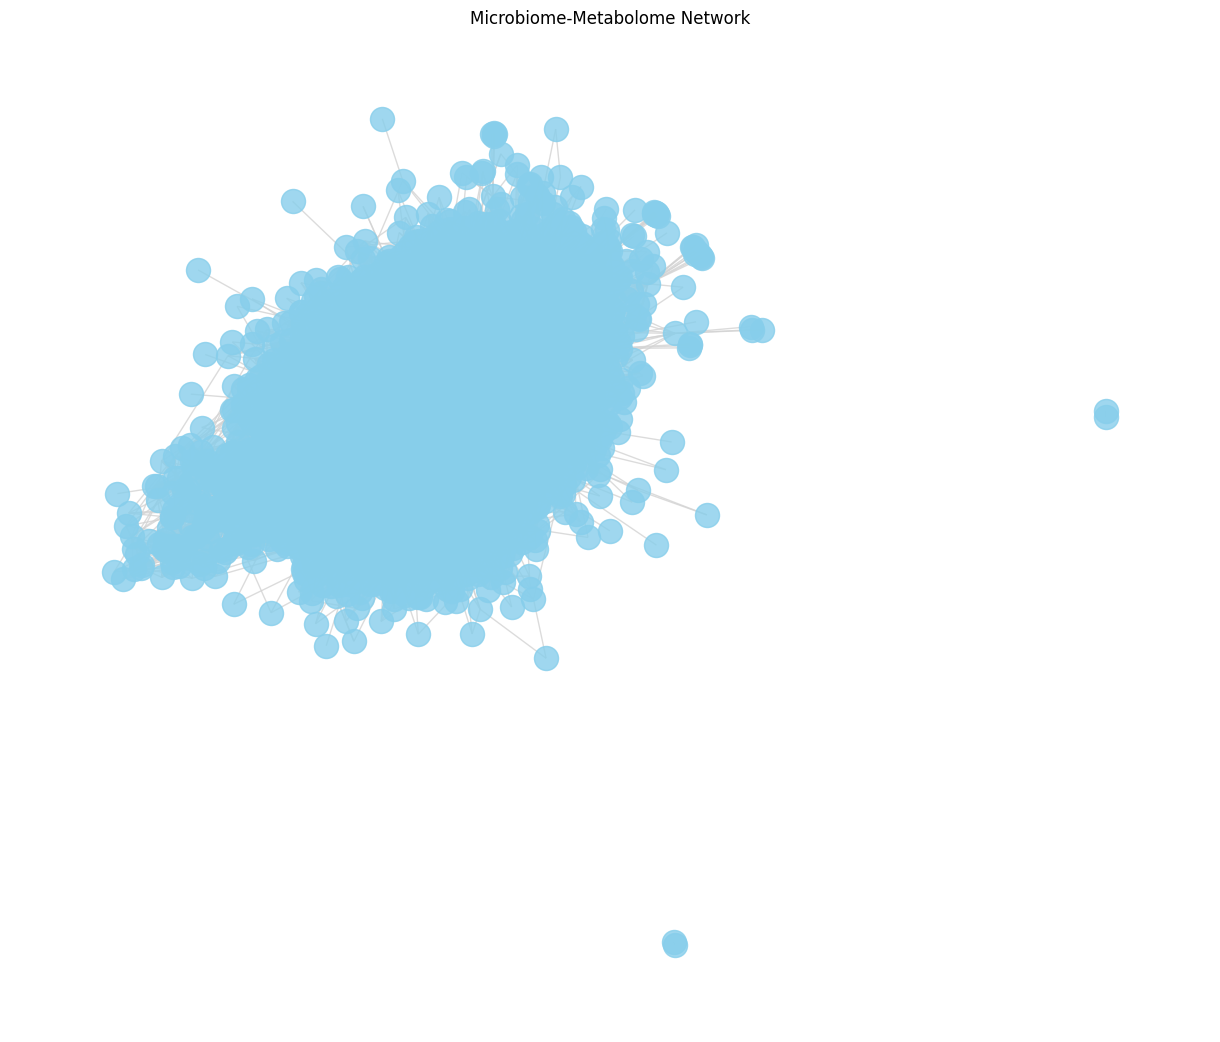

In [47]:
plt.figure(figsize=(12, 10))

# Create a layout for nodes
pos = nx.spring_layout(G_unhealthy, k=0.15, seed=42) 

# Draw the network
nx.draw(G_unhealthy, pos, 
        with_labels=False, 
        node_size=300, 
        node_color='skyblue', 
        edge_color='#D3D3D3', # Light gray for edges
        font_size=7, 
        alpha=0.8)

plt.title("Unhealthy Network")
plt.show()

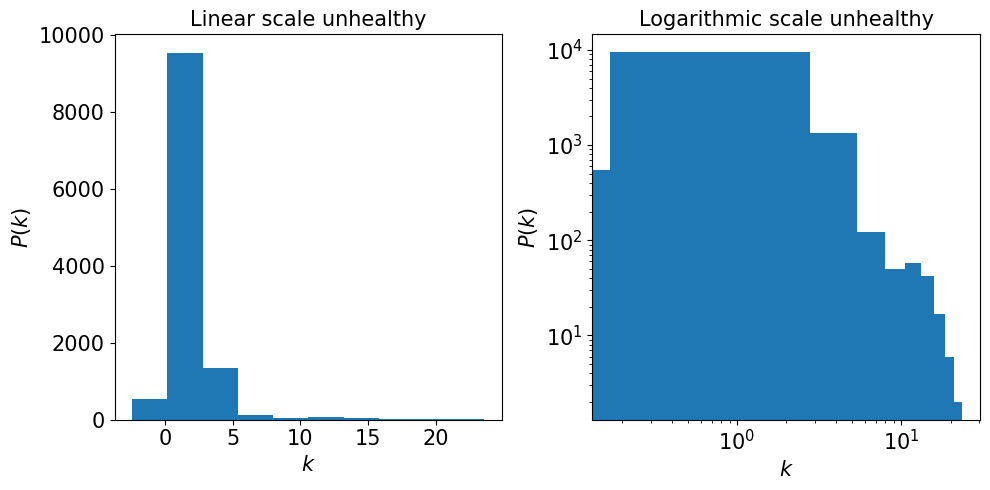

In [ ]:

fig,ax=plt.subplots(1,2,figsize=(10,5))
degree_sequence=[G_unhealthy.degree(node, weight='weight') for node in G_unhealthy.nodes()]
from collections import Counter



ax[0].hist(degree_sequence, bins=10, label='data')
ax[1].hist(degree_sequence, bins=10, label='data')

ax[0].set_xlabel('$k$',fontsize=15)  ### Set label of the axis
ax[0].set_ylabel('$P(k)$',fontsize=15)

ax[1].set_xlabel('$k$',fontsize=15) ### Set label of the axis
ax[1].set_ylabel('$P(k)$',fontsize=15) 

ax[1].set_yscale('log') ### Set logarithmic scale
ax[1].set_xscale('log')

ax[0].tick_params(which='major',axis='both',labelsize=15) ### Size labels ticks
ax[1].tick_params(which='major',axis='both',labelsize=15)


ax[0].set_title('Linear scale unhealthy',fontsize=15)
ax[1].set_title('Logarithmic scale unhealthy',fontsize=15)
fig.tight_layout()



In [11]:
def plot_log_binning(G, num_bins=10):
    degree_sequence = [G.degree(n) for n in G.nodes() if G.degree(n) > 0]
    num_nodes = len(G.nodes())
    
    min_deg, max_deg = min(degree_sequence), max(degree_sequence)
    bins = np.logspace(np.log10(min_deg), np.log10(max_deg), num_bins + 1)
    
    counts, bin_edges = np.histogram(degree_sequence, bins=bins)
    
    # Normalize
    bin_widths = np.diff(bin_edges)
    density = counts / (num_nodes * bin_widths)
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    idx = density > 0
    log_k = np.log10(bin_centers[idx])
    log_P = np.log10(density[idx])
    
    m, b = np.polyfit(log_k, log_P, 1)
    
    theoretical_P = 10**(m * np.log10(bin_centers) + b)
    
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.scatter(bin_centers, density)

    ax.plot(bin_centers, theoretical_P, 'k-', label=f'$\\gamma = {-m:.2f}$')
    
    # Set both axes to log scale
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    ax.set_xlabel('$k$', fontsize=15)
    ax.set_ylabel('$P(k)$', fontsize=15)
    ax.set_title('Degree Distribution (Log Binning)', fontsize=15)
    ax.legend()

    fig.tight_layout()
    plt.show()

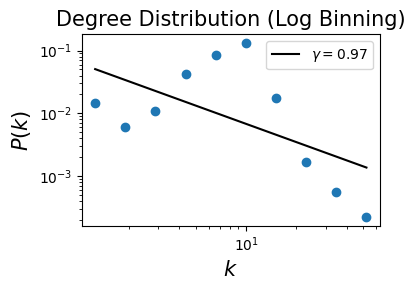

In [20]:
plot_log_binning(G_unhealthy, num_bins=10)

In [44]:
positive_weights = sum(1 for u, v, data in G_unhealthy.edges(data=True) if data.get('weight', 0) > 0)
negative_weights = sum(1 for u, v, data in G_unhealthy.edges(data=True) if data.get('weight', 0) < 0)
zero_weights = sum(1 for u, v, data in G_unhealthy.edges(data=True) if data.get('weight', 0) == 0)

print(f"Positive weights: {positive_weights}")
print(f"Negative weights: {negative_weights}")
print(f"Zero weights: {zero_weights}")

Positive weights: 49526
Negative weights: 5592
Zero weights: 0


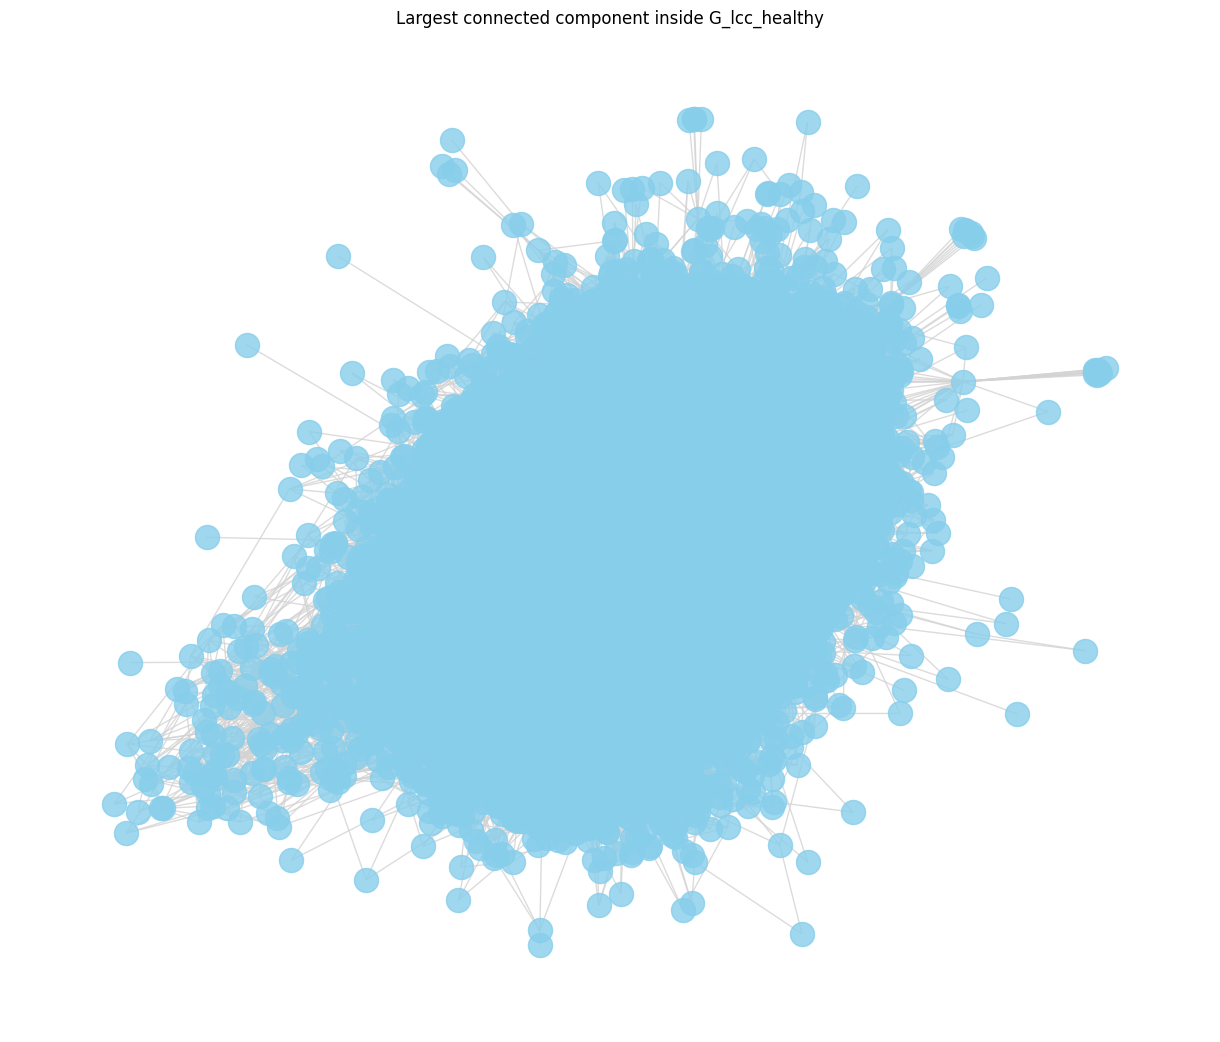

In [89]:
# plot the largest connected component inside G_healthy
lcc_in_lcc = max(nx.connected_components(G_unhealthy), key=len)
G_lcc_in_lcc = G_unhealthy.subgraph(lcc_in_lcc).copy()

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_lcc_in_lcc, k=0.15, seed=42)

nx.draw(G_lcc_in_lcc, pos,
	with_labels=False,
	node_size=300,
	node_color='skyblue',
	edge_color='#D3D3D3',
	alpha=0.8)

plt.title("Largest connected component inside G_lcc_healthy")
plt.show()

# Healthy Abundant 10%

In [4]:
G_healthy_abundant = nx.read_edgelist("df_healthy_abundant_genera.edgelist", data=[("weight", float)])

In [5]:
structural_characterization(G_healthy_abundant)

Number of nodes: 1168
Number of edges: 2254
Minimum Degree: 1
Maximum Degree: 16
Average Degree: 3.86
Average Clustering Coefficient: 0.0039
Assortativity Coefficient (r): -0.0745
Average Shortest Path Length: 5.61
Diameter: 11
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


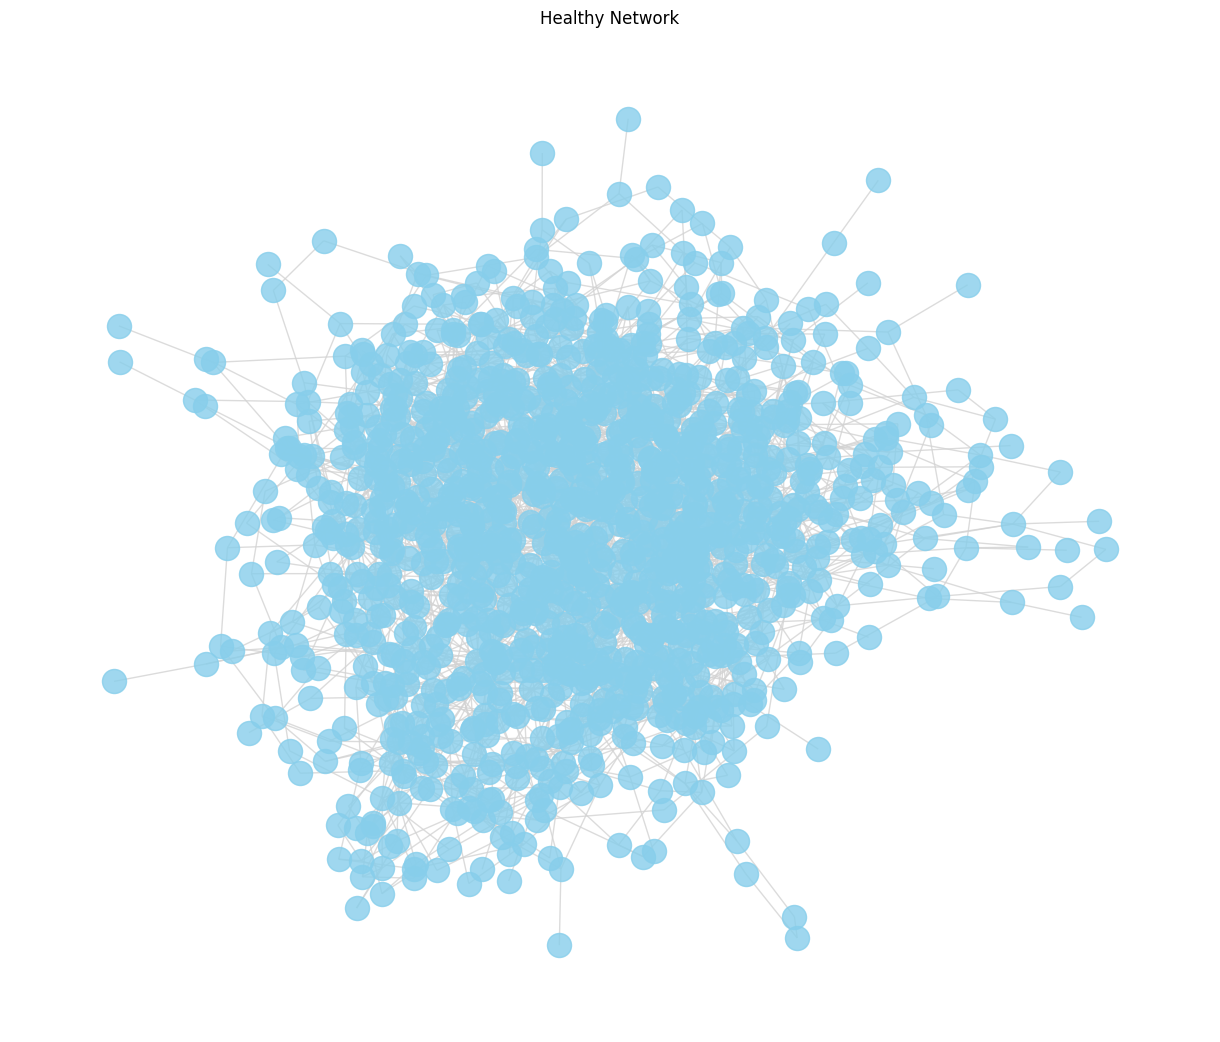

In [8]:
plt.figure(figsize=(12, 10))

# Create a layout for nodes
pos = nx.spring_layout(G_healthy_abundant, k=0.15, seed=42) 

# Draw the network
nx.draw(G_healthy_abundant, pos, 
        with_labels=False, 
        node_size=300, 
        node_color='skyblue', 
        edge_color='#D3D3D3', # Light gray for edges
        font_size=7, 
        alpha=0.8)

plt.title("Healthy Network")
plt.show()

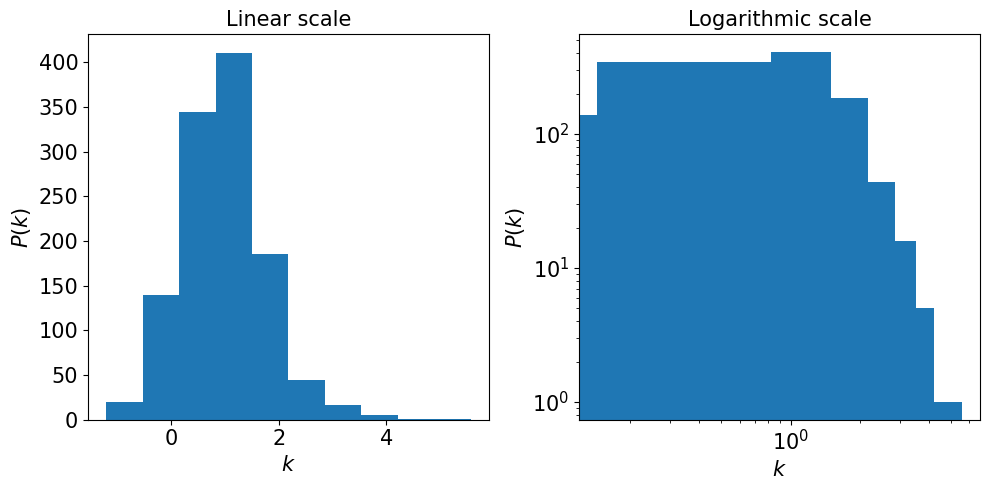

In [6]:

fig,ax=plt.subplots(1,2,figsize=(10,5))
degree_sequence=[G_healthy_abundant.degree(node, weight='weight') for node in G_healthy_abundant.nodes()]
from collections import Counter



ax[0].hist(degree_sequence, bins=10, label='data')
ax[1].hist(degree_sequence, bins=10, label='data')

ax[0].set_xlabel('$k$',fontsize=15)  ### Set label of the axis
ax[0].set_ylabel('$P(k)$',fontsize=15)

ax[1].set_xlabel('$k$',fontsize=15) ### Set label of the axis
ax[1].set_ylabel('$P(k)$',fontsize=15) 

ax[1].set_yscale('log') ### Set logarithmic scale
ax[1].set_xscale('log')

ax[0].tick_params(which='major',axis='both',labelsize=15) ### Size labels ticks
ax[1].tick_params(which='major',axis='both',labelsize=15)


ax[0].set_title('Linear scale',fontsize=15)
ax[1].set_title('Logarithmic scale',fontsize=15)
fig.tight_layout()



In [7]:
positive_weights = sum(1 for u, v, data in G_healthy_abundant.edges(data=True) if data.get('weight', 0) > 0)
negative_weights = sum(1 for u, v, data in G_healthy_abundant.edges(data=True) if data.get('weight', 0) < 0)
zero_weights = sum(1 for u, v, data in G_healthy_abundant.edges(data=True) if data.get('weight', 0) == 0)

print(f"Positive weights: {positive_weights}")
print(f"Negative weights: {negative_weights}")
print(f"Zero weights: {zero_weights}")

Positive weights: 1832
Negative weights: 422
Zero weights: 0


In [26]:
# 1. Load your edgelist
# Adjust 'sep' to ',' if it's a CSV, or '\t' if it's a TSV/FlashWeave output
G_healthy_abundant_df = pd.read_csv('df_healthy_abundant_genera.edgelist', sep='\t', names=['source', 'target', 'weight'])

# Ensure weight is a float (handling the TypeError you might have seen before)
G_healthy_abundant_df['weight'] = G_healthy_abundant_df['weight'].astype(float)

# 2. Calculate the components of the formula
# sum_pos = Σ ω+ (sum of all positive weights)
sum_pos = G_healthy_abundant_df.loc[G_healthy_abundant_df['weight'] > 0, 'weight'].sum()

# sum_neg = Σ ω- (sum of absolute values of negative weights)
sum_neg = G_healthy_abundant_df.loc[G_healthy_abundant_df['weight'] < 0, 'weight'].abs().sum()

# 3. Calculate Inferred Net Interaction
rho_inferred = (sum_pos - sum_neg) / (sum_pos + sum_neg)

print(f"Total Positive Weight Sum: {sum_pos}")
print(f"Total Negative Weight Sum (Absolute): {sum_neg}")
print(f"Inferred Net Interaction (ρ): {rho_inferred:.4f}")

Total Positive Weight Sum: 723.0422977555716
Total Negative Weight Sum (Absolute): 152.63515677866678
Inferred Net Interaction (ρ): 0.6514


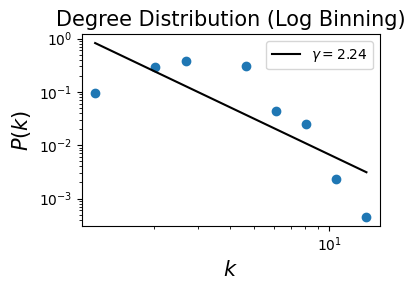

In [12]:
plot_log_binning(G_healthy_abundant, num_bins=10)

# Unhealthy Abundant 10%

In [14]:
G_unhealthy_abundant = nx.read_edgelist("df_unhealthy_abundant_genera.edgelist", data=[("weight", float)])

In [21]:
positive_weights = sum(1 for u, v, data in G_unhealthy_abundant.edges(data=True) if data.get('weight', 0) > 0)
negative_weights = sum(1 for u, v, data in G_unhealthy_abundant.edges(data=True) if data.get('weight', 0) < 0)
zero_weights = sum(1 for u, v, data in G_unhealthy_abundant.edges(data=True) if data.get('weight', 0) == 0)

print(f"Positive weights: {positive_weights}")
print(f"Negative weights: {negative_weights}")
print(f"Zero weights: {zero_weights}")

Positive weights: 3498
Negative weights: 646
Zero weights: 0


In [25]:
# 1. Load your edgelist
# Adjust 'sep' to ',' if it's a CSV, or '\t' if it's a TSV/FlashWeave output
G_unhealthy_abundant_df = pd.read_csv('df_unhealthy_abundant_genera.edgelist', sep='\t', names=['source', 'target', 'weight'])

# Ensure weight is a float (handling the TypeError you might have seen before)
G_unhealthy_abundant_df['weight'] = G_unhealthy_abundant_df['weight'].astype(float)

# 2. Calculate the components of the formula
# sum_pos = Σ ω+ (sum of all positive weights)
sum_pos = G_unhealthy_abundant_df.loc[G_unhealthy_abundant_df['weight'] > 0, 'weight'].sum()

# sum_neg = Σ ω- (sum of absolute values of negative weights)
sum_neg = G_unhealthy_abundant_df.loc[G_unhealthy_abundant_df['weight'] < 0, 'weight'].abs().sum()

# 3. Calculate Inferred Net Interaction
rho_inferred = (sum_pos - sum_neg) / (sum_pos + sum_neg)

print(f"Total Positive Weight Sum: {sum_pos}")
print(f"Total Negative Weight Sum (Absolute): {sum_neg}")
print(f"Inferred Net Interaction (ρ): {rho_inferred:.4f}")

Total Positive Weight Sum: 785.6943518023259
Total Negative Weight Sum (Absolute): 127.63024717825147
Inferred Net Interaction (ρ): 0.7205


In [15]:
structural_characterization(G_unhealthy_abundant)

Number of nodes: 1182
Number of edges: 4144
Minimum Degree: 2
Maximum Degree: 22
Average Degree: 7.01
Average Clustering Coefficient: 0.0304
Assortativity Coefficient (r): -0.0268
Average Shortest Path Length: 4.00
Diameter: 7
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


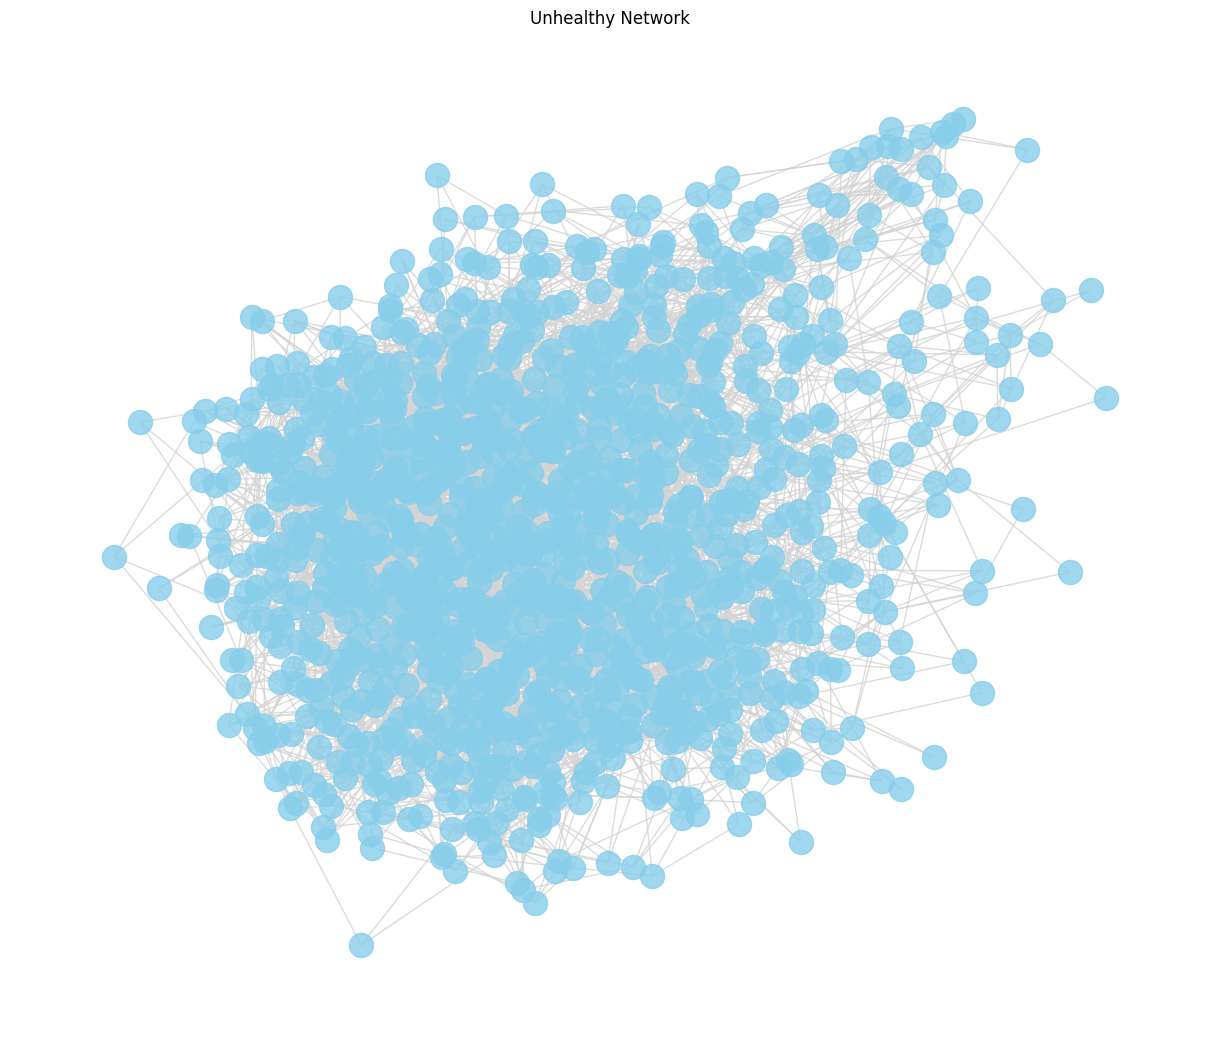

In [16]:
plt.figure(figsize=(12, 10))

# Create a layout for nodes
pos = nx.spring_layout(G_unhealthy_abundant, k=0.15, seed=42) 

# Draw the network
nx.draw(G_unhealthy_abundant, pos, 
        with_labels=False, 
        node_size=300, 
        node_color='skyblue', 
        edge_color='#D3D3D3', # Light gray for edges
        font_size=7, 
        alpha=0.8)

plt.title("Unhealthy Network")
plt.show()

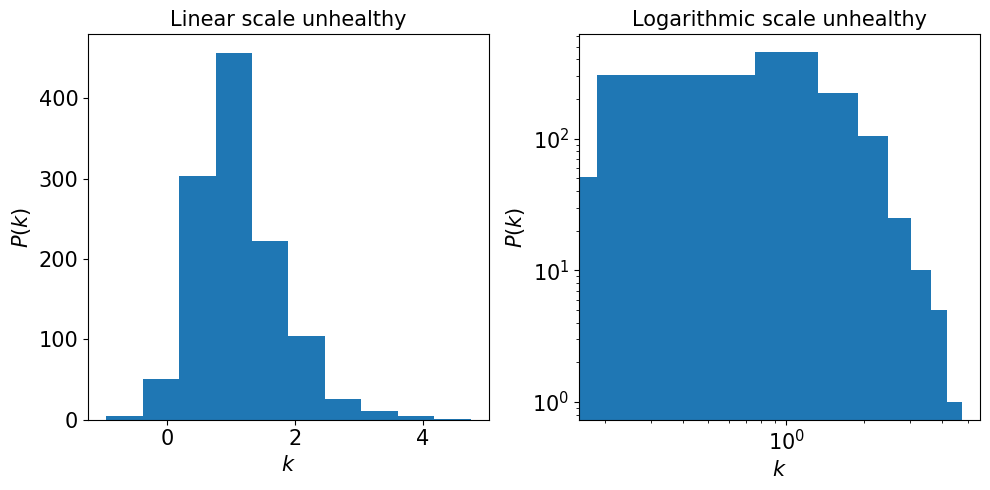

In [17]:

fig,ax=plt.subplots(1,2,figsize=(10,5))
degree_sequence=[G_unhealthy_abundant.degree(node, weight='weight') for node in G_unhealthy_abundant.nodes()]
from collections import Counter



ax[0].hist(degree_sequence, bins=10, label='data')
ax[1].hist(degree_sequence, bins=10, label='data')

ax[0].set_xlabel('$k$',fontsize=15)  ### Set label of the axis
ax[0].set_ylabel('$P(k)$',fontsize=15)

ax[1].set_xlabel('$k$',fontsize=15) ### Set label of the axis
ax[1].set_ylabel('$P(k)$',fontsize=15) 

ax[1].set_yscale('log') ### Set logarithmic scale
ax[1].set_xscale('log')

ax[0].tick_params(which='major',axis='both',labelsize=15) ### Size labels ticks
ax[1].tick_params(which='major',axis='both',labelsize=15)


ax[0].set_title('Linear scale unhealthy',fontsize=15)
ax[1].set_title('Logarithmic scale unhealthy',fontsize=15)
fig.tight_layout()



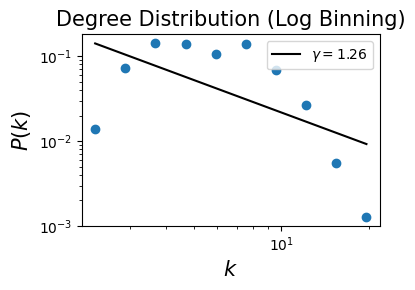

In [18]:
plot_log_binning(G_unhealthy_abundant, num_bins=10)

# Healthy Abundant 20%

In [33]:
G_healthy_abundant = nx.read_edgelist("network_healthy_20.edgelist", data=[("weight", float)])

In [34]:
structural_characterization(G_healthy_abundant)

Number of nodes: 2320
Number of edges: 4673
Minimum Degree: 1
Maximum Degree: 20
Average Degree: 4.03
Average Clustering Coefficient: 0.0016
Assortativity Coefficient (r): -0.0422
Graph is not connected, using largest connected component
Average Shortest Path Length: 5.87
Diameter: 12
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


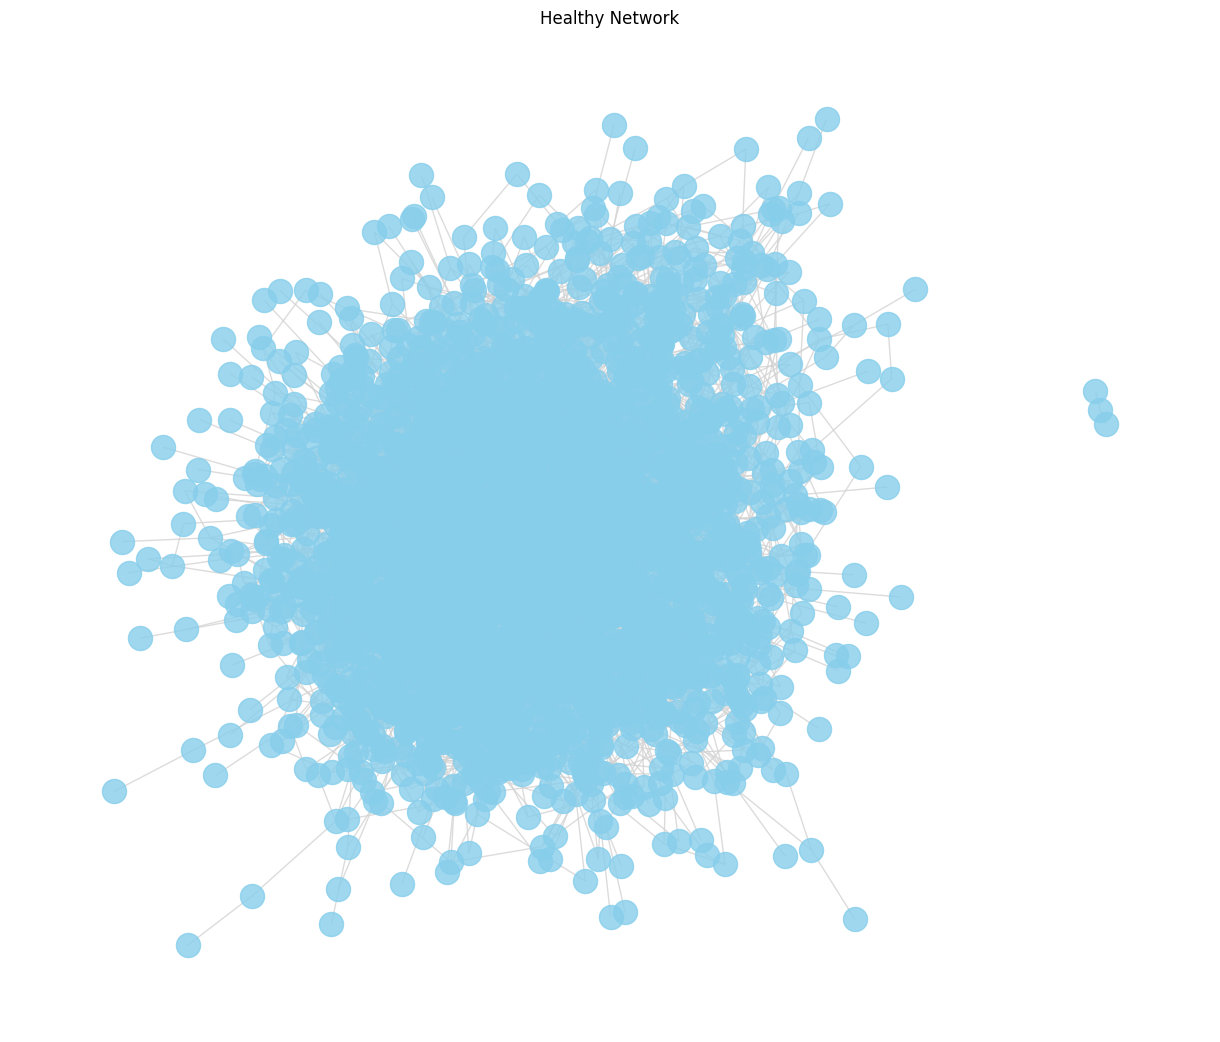

In [35]:
plt.figure(figsize=(12, 10))

# Create a layout for nodes
pos = nx.spring_layout(G_healthy_abundant, k=0.15, seed=42) 

# Draw the network
nx.draw(G_healthy_abundant, pos, 
        with_labels=False, 
        node_size=300, 
        node_color='skyblue', 
        edge_color='#D3D3D3', # Light gray for edges
        font_size=7, 
        alpha=0.8)

plt.title("Healthy Network")
plt.show()

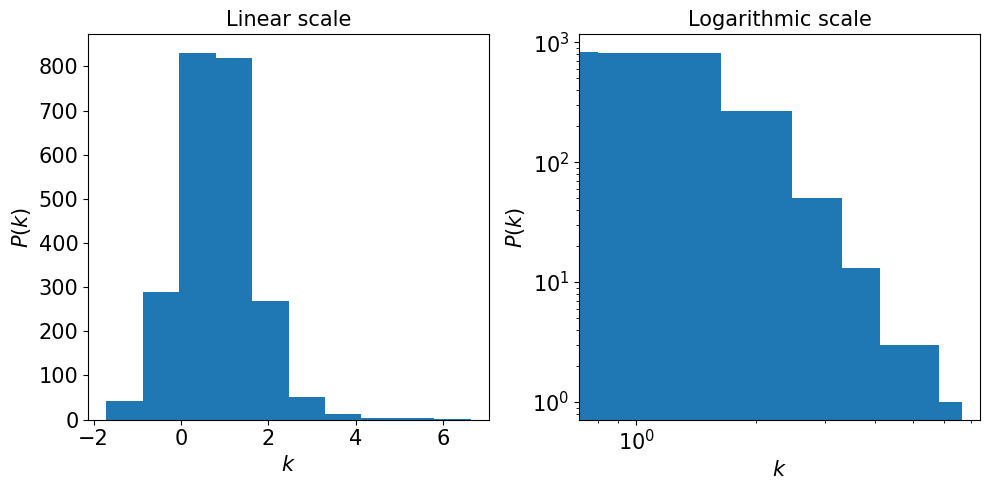

In [36]:

fig,ax=plt.subplots(1,2,figsize=(10,5))
degree_sequence=[G_healthy_abundant.degree(node, weight='weight') for node in G_healthy_abundant.nodes()]
from collections import Counter



ax[0].hist(degree_sequence, bins=10, label='data')
ax[1].hist(degree_sequence, bins=10, label='data')

ax[0].set_xlabel('$k$',fontsize=15)  ### Set label of the axis
ax[0].set_ylabel('$P(k)$',fontsize=15)

ax[1].set_xlabel('$k$',fontsize=15) ### Set label of the axis
ax[1].set_ylabel('$P(k)$',fontsize=15) 

ax[1].set_yscale('log') ### Set logarithmic scale
ax[1].set_xscale('log')

ax[0].tick_params(which='major',axis='both',labelsize=15) ### Size labels ticks
ax[1].tick_params(which='major',axis='both',labelsize=15)


ax[0].set_title('Linear scale',fontsize=15)
ax[1].set_title('Logarithmic scale',fontsize=15)
fig.tight_layout()



In [37]:
positive_weights = sum(1 for u, v, data in G_healthy_abundant.edges(data=True) if data.get('weight', 0) > 0)
negative_weights = sum(1 for u, v, data in G_healthy_abundant.edges(data=True) if data.get('weight', 0) < 0)
zero_weights = sum(1 for u, v, data in G_healthy_abundant.edges(data=True) if data.get('weight', 0) == 0)

print(f"Positive weights: {positive_weights}")
print(f"Negative weights: {negative_weights}")
print(f"Zero weights: {zero_weights}")

Positive weights: 3541
Negative weights: 1132
Zero weights: 0


In [38]:
# 1. Load your edgelist
# Adjust 'sep' to ',' if it's a CSV, or '\t' if it's a TSV/FlashWeave output
G_healthy_abundant_df = pd.read_csv('network_healthy_20.edgelist', sep='\t', names=['source', 'target', 'weight'])

# Ensure weight is a float (handling the TypeError you might have seen before)
G_healthy_abundant_df['weight'] = G_healthy_abundant_df['weight'].astype(float)

# 2. Calculate the components of the formula
# sum_pos = Σ ω+ (sum of all positive weights)
sum_pos = G_healthy_abundant_df.loc[G_healthy_abundant_df['weight'] > 0, 'weight'].sum()

# sum_neg = Σ ω- (sum of absolute values of negative weights)
sum_neg = G_healthy_abundant_df.loc[G_healthy_abundant_df['weight'] < 0, 'weight'].abs().sum()

# 3. Calculate Inferred Net Interaction
rho_inferred = (sum_pos - sum_neg) / (sum_pos + sum_neg)

print(f"Total Positive Weight Sum: {sum_pos}")
print(f"Total Negative Weight Sum (Absolute): {sum_neg}")
print(f"Inferred Net Interaction (ρ): {rho_inferred:.4f}")

Total Positive Weight Sum: 1374.4997519173376
Total Negative Weight Sum (Absolute): 419.50373863462295
Inferred Net Interaction (ρ): 0.5323


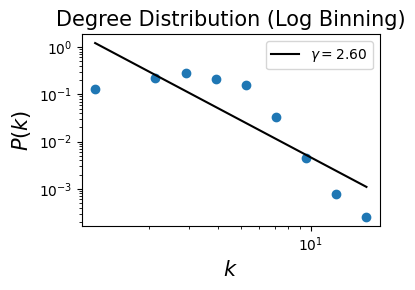

In [39]:
plot_log_binning(G_healthy_abundant, num_bins=10)

# Unhealthy Abundant 20%

In [42]:
G_unhealthy_abundant = nx.read_edgelist("network_unhealthy_20.edgelist", data=[("weight", float)])

In [45]:
structural_characterization(G_unhealthy_abundant)

Number of nodes: 2367
Number of edges: 9480
Minimum Degree: 1
Maximum Degree: 31
Average Degree: 8.01
Average Clustering Coefficient: 0.0134
Assortativity Coefficient (r): 0.0274
Average Shortest Path Length: 4.05
Diameter: 7
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [43]:
positive_weights = sum(1 for u, v, data in G_unhealthy_abundant.edges(data=True) if data.get('weight', 0) > 0)
negative_weights = sum(1 for u, v, data in G_unhealthy_abundant.edges(data=True) if data.get('weight', 0) < 0)
zero_weights = sum(1 for u, v, data in G_unhealthy_abundant.edges(data=True) if data.get('weight', 0) == 0)

print(f"Positive weights: {positive_weights}")
print(f"Negative weights: {negative_weights}")
print(f"Zero weights: {zero_weights}")

Positive weights: 7377
Negative weights: 2103
Zero weights: 0


In [44]:
# 1. Load your edgelist
# Adjust 'sep' to ',' if it's a CSV, or '\t' if it's a TSV/FlashWeave output
G_unhealthy_abundant_df = pd.read_csv('network_unhealthy_20.edgelist', sep='\t', names=['source', 'target', 'weight'])

# Ensure weight is a float (handling the TypeError you might have seen before)
G_unhealthy_abundant_df['weight'] = G_unhealthy_abundant_df['weight'].astype(float)

# 2. Calculate the components of the formula
# sum_pos = Σ ω+ (sum of all positive weights)
sum_pos = G_unhealthy_abundant_df.loc[G_unhealthy_abundant_df['weight'] > 0, 'weight'].sum()

# sum_neg = Σ ω- (sum of absolute values of negative weights)
sum_neg = G_unhealthy_abundant_df.loc[G_unhealthy_abundant_df['weight'] < 0, 'weight'].abs().sum()

# 3. Calculate Inferred Net Interaction
rho_inferred = (sum_pos - sum_neg) / (sum_pos + sum_neg)

print(f"Total Positive Weight Sum: {sum_pos}")
print(f"Total Negative Weight Sum (Absolute): {sum_neg}")
print(f"Inferred Net Interaction (ρ): {rho_inferred:.4f}")

Total Positive Weight Sum: 1592.468200165081
Total Negative Weight Sum (Absolute): 416.50953232531197
Inferred Net Interaction (ρ): 0.5854


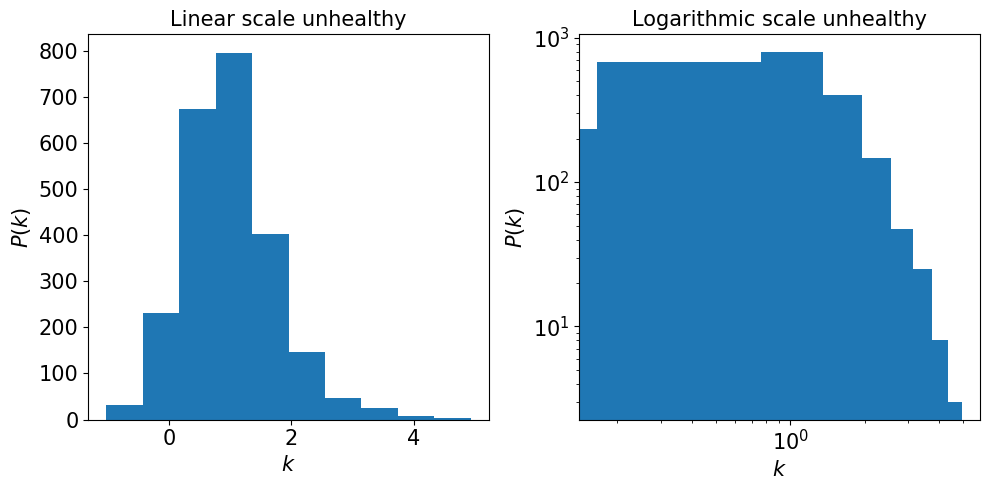

In [46]:

fig,ax=plt.subplots(1,2,figsize=(10,5))
degree_sequence=[G_unhealthy_abundant.degree(node, weight='weight') for node in G_unhealthy_abundant.nodes()]
from collections import Counter



ax[0].hist(degree_sequence, bins=10, label='data')
ax[1].hist(degree_sequence, bins=10, label='data')

ax[0].set_xlabel('$k$',fontsize=15)  ### Set label of the axis
ax[0].set_ylabel('$P(k)$',fontsize=15)

ax[1].set_xlabel('$k$',fontsize=15) ### Set label of the axis
ax[1].set_ylabel('$P(k)$',fontsize=15) 

ax[1].set_yscale('log') ### Set logarithmic scale
ax[1].set_xscale('log')

ax[0].tick_params(which='major',axis='both',labelsize=15) ### Size labels ticks
ax[1].tick_params(which='major',axis='both',labelsize=15)


ax[0].set_title('Linear scale unhealthy',fontsize=15)
ax[1].set_title('Logarithmic scale unhealthy',fontsize=15)
fig.tight_layout()



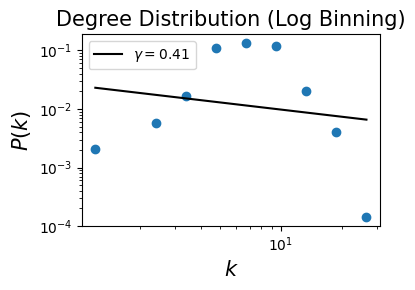

In [47]:
plot_log_binning(G_unhealthy_abundant, num_bins=10)